In [13]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

# conda clean --all

In [14]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_susceptibility = 1j * copper_conductivity / (omega * epsilon_0) # copper susceptance in dimensionless units
print(f"Copper susceptance: {copper_susceptibility:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper susceptance: 0.00e+00+4.37e+08j


In [15]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
# Zs = 1 / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_matrix.txt", delimiter=',') # lossy matrix
R0 = np.loadtxt(r"R0_matrix.txt", delimiter=',') # radiated power matrix
X0 = np.loadtxt(r"X0_matrix.txt", delimiter=',') # reactive power matrix
Vinc = E0*np.loadtxt(r"V_vector.txt", delimiter=',') # voltage excitation vector

Urwg = np.loadtxt(r"Urwg_matrix.txt", delimiter=',') # structural modes matrix

Zmat = Zs * Lmat # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Rmat = np.real(Zmat) # rezistivity matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Vzero = np.zeros((Ndes,), dtype=complex) # zero vector

Obj = -0.5 * R0
obj = Vzero/2
obj0 = 0

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = -np.real(Ifull.conj().T @ Obj @ Ifull) + 2*np.real(Ifull.conj().T @ obj) + obj0 # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


In [16]:
# translate QCQP matrices to Dolphindes notation
Umat = -1j * Ztot.conj() # Dolphindes U matrix
eVec = 1j * Vinc / 2 # Dolphindes e vector
Bmat = Obj # quadratic objective matrix
bVec = obj # linear objective vector
beta = obj0 # constant objective term

Pdiags = np.ones((Ndes,2), dtype=complex) # gloal constraints
Pdiags[:,1] = 1j
Plist = [sp.diags(Pdiags[:,i]) for i in range(Pdiags.shape[1])]

In [17]:
# # preconditioner for projection constraints
# G0 = Z0 # Green's function matrix
# D = np.diag(np.diag(Z0)) # Green's matrix diagonal
# X = np.linalg.inv(Zmat) # material admittance matrix
# H0 = G0 - D
# Y = np.linalg.solve(np.eye(Ndes) + X @ D, X)
# iVec = X @ Vinc

# S = np.eye(Ndes) + Y @ H0 # preconditioner matrix for projection constraints
# q = -Y @ G0 @ iVec
# p = q + S @ iVec

# Sinv = np.linalg.inv(S)

# P0 = Sinv @ Ztot

# sVec = Sinv @ q
# tVec = sVec + iVec
# Vtest = Ztot @ tVec
# print(f"voltage error: {np.max(np.abs(Vtest - Vinc))/np.max(np.abs(Vinc)):.2e}")

# print(f"asymmetric error of preconditioner: {np.linalg.norm(S-S.T, ord='fro')/np.linalg.norm(S, ord='fro'):.2e}")

# obj0p = obj0
# objp = obj
# Objp = Obj

# Ptr0 = -np.real(tVec.conj().T @ Objp @ tVec) + 2*np.real(tVec.conj().T @ objp) + obj0p
# print(f"objective error: {np.abs(Ptr0 - Pfull)/np.abs(Pfull):.2e}")


# realPowerConstraint = np.real(-tVec.conj().T @ -S @ P0 @ tVec + 2*tVec.conj().T @ P0.T @ -p/2)
# realPower = np.real(tVec.conj().T @ S @ P0 @ tVec)

# imagPowerConstraint = np.real(-tVec.conj().T @ -S @ (1j*P0) @ tVec + 2*tVec.conj().T @ (1j*P0).T @ -p/2)
# imagPower = np.real(tVec.conj().T @ S @ (1j*P0) @ tVec)

# print(f"real power error: {np.abs(realPowerConstraint)/np.abs(realPower):.2e}")
# print(f"imaginary power error: {np.abs(imagPowerConstraint)/np.abs(imagPower):.2e}")    

# Umat = -1j * S.conj().T
# eVec = 1j * p/2
# Bmat = Obj
# bVec = obj
# beta = obj0

# # make the Plist to contain matrices P0 and 1j*P0
# Plist = [P0, 1j*P0]

In [18]:
# set up optimization variables
Nopt = Umat.shape[0] # number of optimization variables (after reduction)

QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat, eVec,
                             Plist, verbose = 1
                                )


t1 = time.time()
lags_init = np.zeros((Pdiags.shape[1],))
lags_init[0] = -1

# New interface for specifying optimization hyperparameters. https://dolphindes.readthedocs.io/en/latest/api/dolphindes.cvxopt.OptimizationHyperparameters.html
opt_params = OptimizationHyperparameters(opttol=1e-7,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=1)

# Note: 'newton' is usually faster than BFGS, both are prety fast with so few constraints.
result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
mineigenval = np.min(np.real(eigenvals))


print(f"bound: {result[0]:.4e}, min eigenvalue: {mineigenval:.2e}, time: {time.time()-t1}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
Optimizer initialized with parameters:
opttol: 1e-07
gradConverge: True
min_inner_iter: 10
max_restart: 10
penalty_ratio: 0.01
penalty_reduction: 0.1
break_iter_period: 5
verbose: 1
Starting optimization with x0 = [-1.  0.]
Outer iteration 0, penalty_ratio = 0.01, opt_fx = 12.229409615220947
iter_num: 5, prev_fx: inf, opt_fx: 10.121047852717268, opttol: 1e-07
iter_num: 10, prev_fx: 10.121047852717268, opt_fx: 10.121011744463944, opttol: 1e-07
iter_num: 15, prev_fx: 10.121011744463944, opt_fx: 10.120932760129415, opttol: 1e-07
Outer iteration 1, penalty_ratio = 0.001, opt_fx = 10.120932760124786
iter_num: 5, prev_fx: 10.120932760129415, opt_fx: 10.120932760125303, opttol: 1e-07
bound: 1.0121e+01, min eigenvalue: 1.16e-07, time: 0.28802061080932617s, Lagrange multipliers: [-0.98806808 -0.03777128]


Precomputed 4 A matrices and Fs vectors.
mode: 1, bound: 1.01084803e+01, min eigenvalue: 1.11e-07, time: 0.2608764171600342s
Precomputed 6 A matrices and Fs vectors.
mode: 2, bound: 1.01084803e+01, min eigenvalue: 1.11e-07, time: 0.2982311248779297s
Precomputed 8 A matrices and Fs vectors.
mode: 3, bound: 1.01082425e+01, min eigenvalue: 1.11e-07, time: 0.3788187503814697s
Precomputed 10 A matrices and Fs vectors.
mode: 4, bound: 1.01082425e+01, min eigenvalue: 1.11e-07, time: 0.38394808769226074s
Precomputed 12 A matrices and Fs vectors.
mode: 5, bound: 1.01082201e+01, min eigenvalue: 1.11e-07, time: 0.3721156120300293s
Precomputed 14 A matrices and Fs vectors.
mode: 6, bound: 1.01082201e+01, min eigenvalue: 1.11e-07, time: 0.37840723991394043s
Precomputed 16 A matrices and Fs vectors.
mode: 7, bound: 1.01082161e+01, min eigenvalue: 1.11e-07, time: 0.34696483612060547s
Precomputed 18 A matrices and Fs vectors.
mode: 8, bound: 1.01082159e+01, min eigenvalue: 1.11e-07, time: 0.4000260829

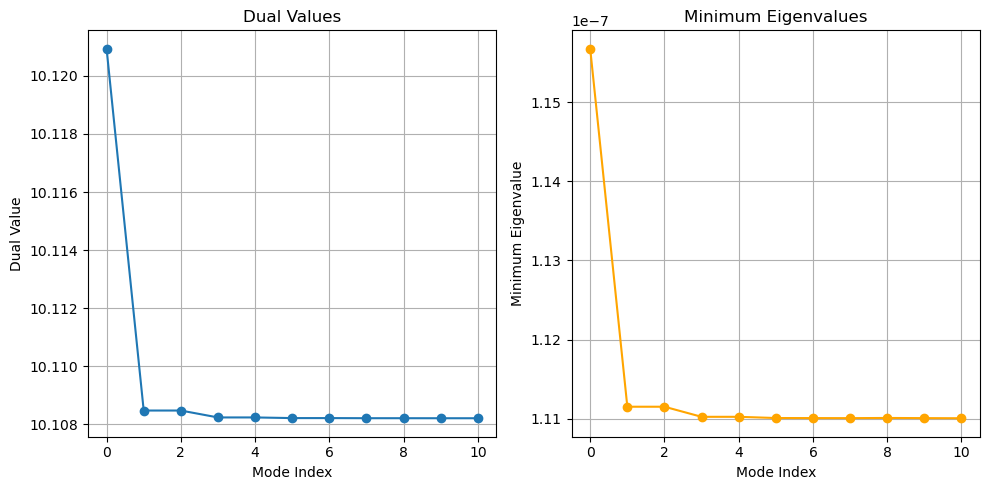

In [19]:
opt_params = OptimizationHyperparameters(opttol=1e-7,                  
    gradConverge=True,           
    min_inner_iter=10,             
    max_restart=10,                
    penalty_ratio=1e-2,           
    penalty_reduction=0.1,        
    break_iter_period=5,          
    verbose=0)
nP = 2
nModes = 10
dual_vals = [result[0]]
min_eigenvalues = [mineigenval]

for iMode in range(nModes):
    nP += 2
        
    # Plist.append(sp.diags(np.abs(Urwg[:,iMode])))
    # Plist.append(sp.diags(1j*np.abs(Urwg[:,iMode])))
    
    Plist.append(sp.diags(Urwg[:,iMode]))
    Plist.append(sp.diags(1j*Urwg[:,iMode]))
    
    lags_init = np.zeros((nP,))
    lags_init[:nP-2] = QCQP.current_lags
    
    QCQP = DenseSharedProjQCQP(Bmat, bVec, beta,
                            Umat, eVec,
                             Plist, verbose = 1
                                )


    t1 = time.time()

    result = QCQP.solve_current_dual_problem(method = 'bfgs', init_lags = lags_init, opt_params = opt_params)
    
    lags = QCQP.current_lags
    totalA = QCQP._get_total_A(lags)
    eigenvals, eigenvecs = np.linalg.eig(totalA)
    mineigenval = np.min(np.real(eigenvals))
    
    dual_vals.append(result[0])
    min_eigenvalues.append(mineigenval)
    
    print(f"mode: {iMode+1}, bound: {result[0]:.8e}, min eigenvalue: {mineigenval:.2e}, time: {time.time()-t1}s")

# plot dual values and minimum eigenvalues
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(nModes+1), dual_vals, marker='o')
plt.title('Dual Values')
plt.xlabel('Mode Index')
plt.ylabel('Dual Value')
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(range(nModes+1), min_eigenvalues, marker='o', color='orange')
plt.title('Minimum Eigenvalues')
plt.xlabel('Mode Index')
plt.ylabel('Minimum Eigenvalue')
plt.grid()
plt.tight_layout()
plt.show()  

minimal eigenvalue: 1.1100604334383305e-07
[1.27824683e-07+7.56335022e-24j 1.11006043e-07-1.17860828e-23j
 2.96248165e-07+1.06046783e-22j]


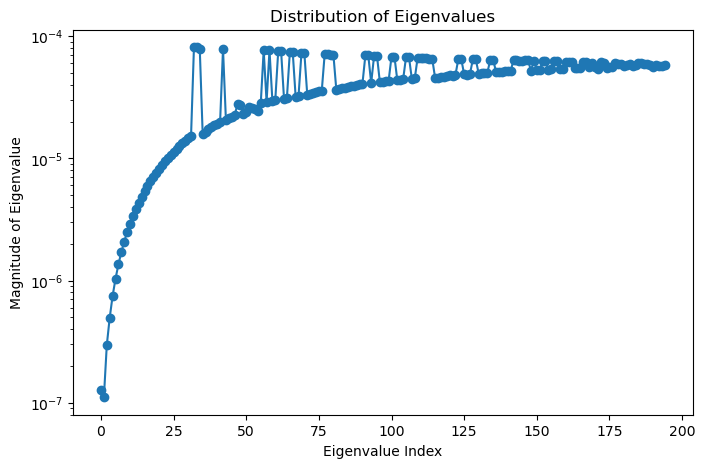

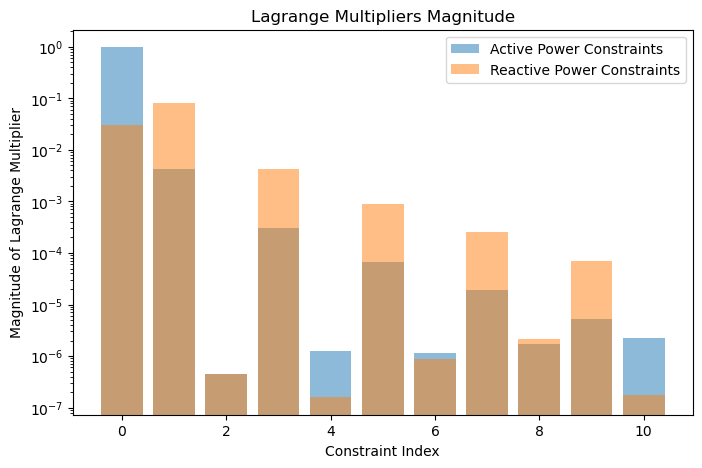

In [20]:
# Now let's check again for PSD of A. We don't expect the constraints to hold or to have strong duality
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
eigenvals, eigenvecs = np.linalg.eig(totalA)
print(f"minimal eigenvalue: {np.min(np.real(eigenvals))}")
print(f"{eigenvals[0:3]}")

# plot logscale real(eigenvals)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.semilogy(np.arange(len(np.real(eigenvals))), np.real(eigenvals), 'o-')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Magnitude of Eigenvalue')
plt.title('Distribution of Eigenvalues')
plt.show()

lagsR = lags[0::2]
lagsI = lags[1::2]

# plot logscale abs(lags)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(lagsR)), np.abs(lagsR), alpha=0.5, label='Active Power Constraints')
plt.bar(np.arange(len(lagsI)), np.abs(lagsI), alpha=0.5, label='Reactive Power Constraints')
plt.xlabel('Constraint Index')
plt.ylabel('Magnitude of Lagrange Multiplier')
plt.title('Lagrange Multipliers Magnitude')
plt.yscale('log')
plt.legend()
plt.show()

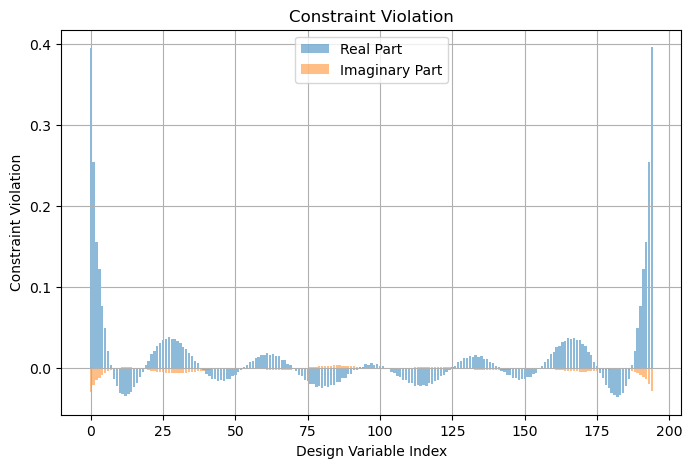

In [21]:
Ivec = QCQP.current_xstar + (0.0032382384093758666-0.021043720313077018j)*eigenvecs[:,0] + (-8.800104359030321-1.598726091569536j)*eigenvecs[:,1]
qLocal= Ivec.conj() * (Umat.conj().T @ Ivec)
lLocal = 2 * Ivec.conj() * eVec
con_violation = 1j*((lLocal - qLocal) / np.abs(0.5*(lLocal + qLocal))).conj() # constraint violation normalized by the magnitude of the constraint value, to get a relative measure of violation. This is more informative than normalizing by lLocal alone, since qLocal can be large and make the violation seem small when it's actually significant.
# plot bar real and imag parts of constraint violation
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Nopt), np.real(con_violation), alpha=0.5, label='Real Part')
plt.bar(np.arange(Nopt), np.imag(con_violation), alpha=0.5, label='Imaginary Part')
plt.xlabel('Design Variable Index')
plt.ylabel('Constraint Violation')
plt.title('Constraint Violation')
plt.legend()
plt.grid(True)
plt.show()

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
inference error: 1.2412677268618333


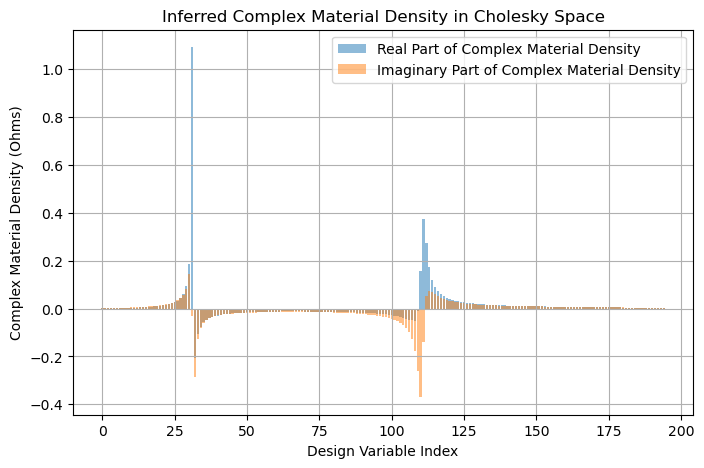

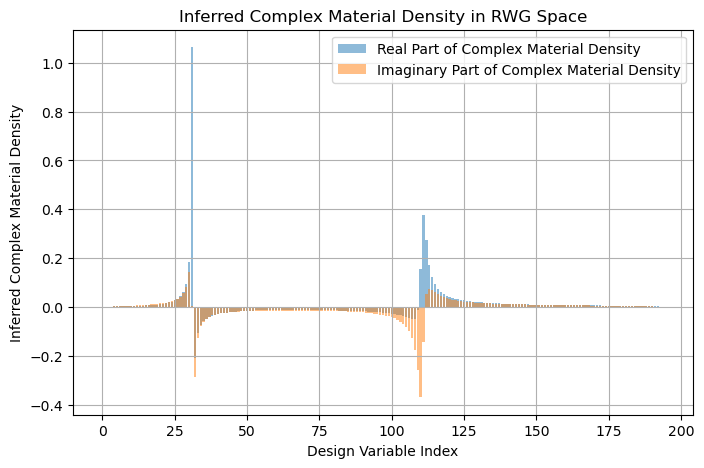

Objective for inferred material density: -1.017260e+01 W


In [34]:
# infer conductivity
Lchol = np.linalg.cholesky(Lmat).conj().T
MfactorInf = np.linalg.inv(Lchol)

# Ivec = np.linalg.solve(Ztot, Vinc) # optimal current distribution in original coordinates

iChol = Lchol @ Ivec
Z0fInf = MfactorInf.conj().T @ Z0 @ MfactorInf
VincfInf = MfactorInf.conj().T @ Vinc

Vopt = Z0fInf @ iChol
Vinf = VincfInf - Vopt
Zinff = Vinf / iChol

# Umd = 1j * np.diag(Pdiags @ lags[0:Pdiags.shape[1]]) @ (Zmatf - np.diag(Zinff)).conj()
# Umds = Umd + Umd.conj().T
# eq4 = (iChol.conj().T @ Umds @ iChol)/(iChol.conj().T @ Zmatf @ iChol)
# print(f"eq4 value normalized by squared norm: {eq4}, expected to be close to zero for consistency with GCD solution")


print(f"Surface impedance: {Zs} Ω")

complexMaterialDensityChol = Zs / Zinff
print(f"inference error: {np.max(np.abs(complexMaterialDensityChol - 1))}")

# bar plot with real and imaginary parts of Zinf for Ndes design variables
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensityChol), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensityChol), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Complex Material Density (Ohms)')
plt.title('Inferred Complex Material Density in Cholesky Space')
plt.legend()
plt.grid(True)
plt.show()


Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
diagZinf = np.diag(Zinf)
diagZmat = np.diag(Zmat)


complexMaterialDensity = diagZmat / diagZinf

plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), np.real(complexMaterialDensity), alpha=0.5, label='Real Part of Complex Material Density')
plt.bar(np.arange(Ndes), np.imag(complexMaterialDensity), alpha=0.5, label='Imaginary Part of Complex Material Density')
plt.xlabel('Design Variable Index')
plt.ylabel('Inferred Complex Material Density')
plt.title('Inferred Complex Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

# evaluate performmance for inferred material density
ZtotInf = Z0 + Zinf
IfullInf = np.linalg.solve(ZtotInf, Vinc) # current distribution for inferred material density
PfullInf = np.real(IfullInf.conj().T @ Obj @ IfullInf) # radiated power for inferred material density
print(f"Objective for inferred material density: {PfullInf:.6e} W")


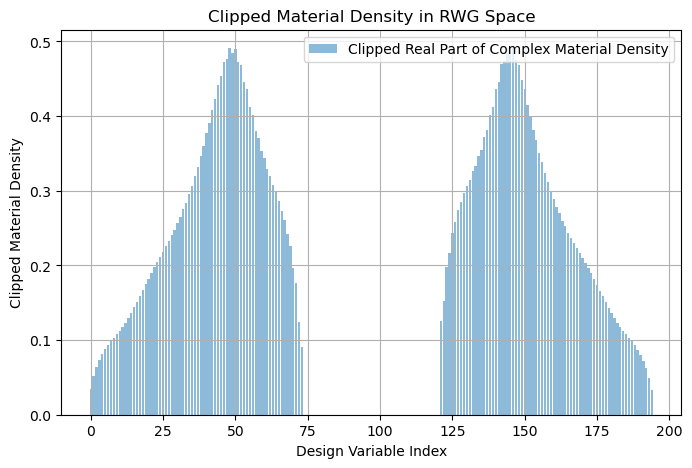

Objective for limited inferred material density: -6.10639168e-03 W


In [23]:
# limit material density to be postive real [0,1]
material_density = np.sqrt(np.clip(np.real(complexMaterialDensity), 1e-9, 1))
plt.figure(figsize=(8, 5))
plt.bar(np.arange(Ndes), material_density, alpha=0.5, label='Clipped Real Part of Complex Material Density')
plt.xlabel('Design Variable Index') 
plt.ylabel('Clipped Material Density')
plt.title('Clipped Material Density in RWG Space')
plt.legend()
plt.grid(True)
plt.show()

addLoss = 1/material_density
ZmatInfLim = np.diag(addLoss) @ Zmat @ np.diag(addLoss)
ZtotInfLim = Z0 + ZmatInfLim
IfullInfLim = np.linalg.solve(ZtotInfLim, Vinc) # current distribution for inferred material density
PfullInfLim = np.real(IfullInfLim.conj().T @ Obj @ IfullInfLim) # radiated power for inferred material density
print(f"Objective for limited inferred material density: {PfullInfLim:.8e} W")

In [33]:
from scipy.optimize import minimize

# --- Assuming these variables are already in your workspace ---
# QCQP_current_xstar = QCQP.current_xstar
# eigenvecs = ... (your matrix of eigenvectors)
# num_modes = 2 # Number of eigenvectors you are adding

def constraint_error_objective(weights_real_imag):
    # 1. Reconstruct complex weights from the 1D real array provided by the optimizer
    # (First half is real part, second half is imaginary part)
    num_modes = len(weights_real_imag) // 2
    weights_complex = weights_real_imag[:num_modes] + 1j * weights_real_imag[num_modes:]
    
    # 2. Construct the new current vector (Ivec)
    Ivec = QCQP.current_xstar.copy()
    for i in range(num_modes):
        Ivec += weights_complex[i] * eigenvecs[:, i]
        
    qLocal= Ivec.conj() * (Umat.conj().T @ Ivec)
    lLocal = 2 * Ivec.conj() * eVec
    con_violation = 1j*((lLocal - qLocal) / np.abs(0.5*(lLocal + qLocal))).conj()
    return np.linalg.norm(con_violation, ord=2)  # Return the L2 norm of the constraint violation

def infer_material_density(Ivec):
    # same inference as in the "infer conductivity" cell above, but as a function of Ivec
    iChol = Lchol @ Ivec
    Vopt = Z0fInf @ iChol
    Vinf = VincfInf - Vopt
    Zinff = Vinf / iChol

    Zinf = Lchol.conj().T @ np.diag(Zinff) @ Lchol
    diagZinf = np.diag(Zinf)
    diagZmat = np.diag(Zmat)

    return diagZmat / diagZinf  # complex material density


def clipping_error_objective(weights_real_imag, num_modes=2, norm_ord=2):
    # clipping error: how far the inferred (real) material density strays from the nearest
    # of {0, 1} at each design variable, aggregated with the given norm
    weights_complex = weights_real_imag[:num_modes] + 1j * weights_real_imag[num_modes:]

    Ivec = QCQP.current_xstar.copy()
    for i in range(num_modes):
        Ivec += weights_complex[i] * eigenvecs[:, i]

    rho = infer_material_density(Ivec)
    dist_to_binary = np.minimum(np.abs(rho), np.abs(1 - rho))

    return np.linalg.norm(dist_to_binary, ord=norm_ord)

# --- Set up and run the optimization ---

num_modes = 2 # Update this if you are using more than 2 eigenvectors
# Initial guess for the weights (0 + 0j for all modes -> mapped to an array of zeros)
# Size is 2 * num_modes to account for real and imaginary parts
initial_guess = np.zeros(2 * num_modes)

print("Starting optimization...")
# Using Nelder-Mead because the np.minimum() function makes the gradient non-smooth
result = minimize(
    clipping_error_objective, initial_guess, method='Nelder-Mead',
    options={
        'disp': True,
        'maxiter': 20000,
        'maxfev': 20000,
        'xatol': 1e-10,
        'fatol': 1e-10,
        'adaptive': True,   # doporučeno pro >1 proměnnou, škáluje simplex parametry podle dimenze
    }
)


# --- Extract and apply the results ---

if result.success:
    # Reconstruct optimal complex weights
    optimal_weights_real_imag = result.x
    optimal_weights_complex = optimal_weights_real_imag[:num_modes] + 1j * optimal_weights_real_imag[num_modes:]
    
    print("\nOptimization successful!")
    print(f"Minimum clipping error achieved: {result.fun:.6f}")
    
    # Print individual weights
    for i in range(num_modes):
        print(f"Optimal weight c_{i}: {optimal_weights_complex[i]}")
        
    # Reconstruct the final optimized Ivec
    Ivec = QCQP.current_xstar.copy()
    for i in range(num_modes):
        Ivec += optimal_weights_complex[i] * eigenvecs[:, i]
        
    # You can now use Ivec_opt for your final plotting or downstream tasks
else:
    print("Optimization failed:", result.message)

Starting optimization...
Optimization terminated successfully.
         Current function value: 0.997145
         Iterations: 758
         Function evaluations: 1512

Optimization successful!
Minimum clipping error achieved: 0.997145
Optimal weight c_0: (-2.5881979916675455-269.0066228731959j)
Optimal weight c_1: (33.200408061828995+361.03271621252094j)
